## Import data

**WARNING**: This script is NOT intended to be run all at once. Proceeed with cautions. 

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

import numpy as np
from gf3merger import config, utils
from gf3merger.merge import GF3Merger

dir_slc = "/data/tests/ruikang/cn_xinjiang_glacier_gf3_test/stack/process/S01B01/"
primary = "20230818"

## Read Image

In [ ]:
# Make sure folder has been backed up
import os

img_dir = os.path.join(dir_slc, primary)

raw_orig = os.path.join(img_dir, "image_crop.raw")
raw_bak = os.path.join(img_dir, "image_crop.raw.bak")

slc = utils.read_rslc(img_dir)

os.rename(raw_orig, raw_bak)



## Change Image

In [ ]:
# Get the shape of the original SLC
rows, cols = slc.shape
# Calculate how many new rows to add
new_rows = 54940 - rows  # This should be 28687
# Create a new array with zeros for the additional rows
additional_rows = np.zeros((new_rows, cols), dtype=slc.dtype)
# Concatenate the original SLC with the additional rows
slc_extended = np.vstack((slc, additional_rows))
# Verify the new shape
print(f"Original shape: {slc.shape}")
print(f"Extended shape: {slc_extended.shape}")


In [ ]:
## Write to local

In [ ]:
utils.write_rslc(slc_extended, raw_orig)

## Merge

In [ ]:
dir_slc = "/data/tests/ruikang/cn_xinjiang_glacier_gf3_test/stack/process/S01B01/"
parent_date = "20230818"
child_date = "20230819"

GF3Merger(dir_slc=dir_slc, parent_date=parent_date, child_date=child_date).merge()

## Plot Merged 20230818

In [ ]:
import os
from PIL import Image
import numpy as np
import matplotlib.image as img

dir_slc = "/data/tests/ruikang/cn_xinjiang_glacier_gf3_test/stack/process/S01B01/"
parent_date = "20240301"

img_dir = os.path.join(dir_slc, parent_date)

slc = utils.read_rslc(img_dir)

# Calculate the magnitude of the complex SLC data
magnitude = np.abs(slc)

# fdem = os.path.join(dir_slc, "dem_radar_ell.raw")
# shape = (54940, 25037)
# rslc_int = np.memmap(filename=fdem, dtype=np.float32, mode="r", offset=0, shape=shape)

decimate = 2
quicklook = rslc_int[::decimate, ::decimate]  # type: ignore

# Save the image
output_path = os.path.join(dir_slc, f"{parent_date}_dem_magnitude.png")
print(f"Image saved to {output_path}")

# # Save as black & white image
# img.imsave(output_path, np.abs(quicklook) * decimate/10,
#            cmap='gray', vmin=0, vmax=10)


Image saved to /data/tests/ruikang/cn_xinjiang_glacier_gf3_test/stack/process/S01B01/20240301_dem_magnitude.png


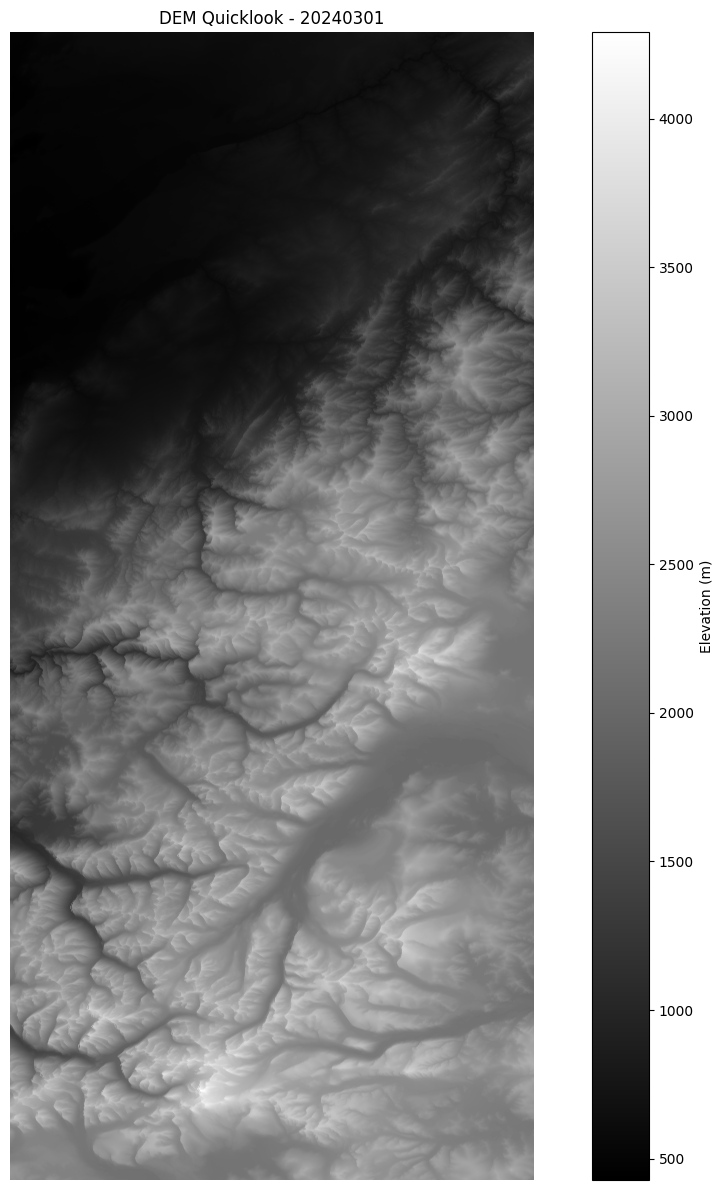

In [12]:
# plot quicklook
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))
plt.imshow(quicklook, cmap='gray')
plt.title(f'DEM Quicklook - {parent_date}')
plt.colorbar(label='Elevation (m)')
plt.axis('off')
plt.tight_layout()
plt.show()
